# Exercise 8

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import time

## Part 1

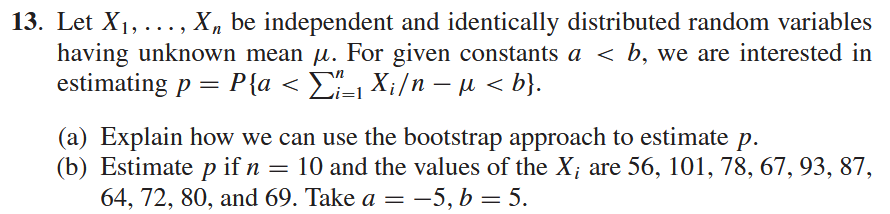

### subtask a)



In [ ]:
#Define emperical distribution function (for plotting)
def EDF(x_samples, x):
    n = np.size(x_samples)
    return np.sum(x_samples <= x) / n

#Define dataset
x_samples = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]    

def bootstrap_p(k=1000, x_samples):
    np.ran

In [ ]:
x_samples = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]  
k=10000
a=-5
b=5
n = np.size(x_samples)

#Estimate mu as sample mean
mu_est = np.mean(x_samples)

#List for Bootstrap replicates (here: mean)
BS_reps = []
for _ in range(k):
    X_BS = np.random.choice(a=x_samples, size=n)
    BS_rep = np.mean(X_BS)
    BS_reps.append(BS_rep)

BS_reps = np.array(BS_reps)

print(np.shape(BS_reps))

#Evaluate p
accept = 0
for i in range(k):
    if a < (BS_reps[i]-mu_est):
        if (BS_reps[i]-mu_est) < b:
            accept +=1

p = accept/k

print(f"results (for k={k}):")
print(f"p={p:.4f}")

(10000,)
results (for k=10000):
p=0.7577


## Part 2

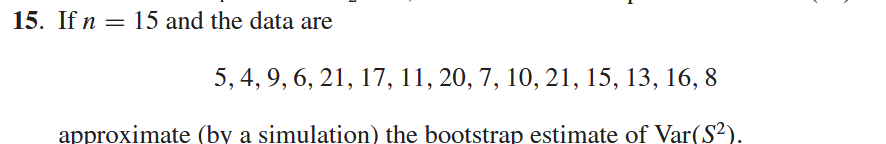

In [ ]:
np.random.seed(42)
x_samples = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]) 
n = np.size(x_samples)
k=10000
#Sample variance
S2 = np.var(a=x_samples, ddof=1)

#List for Bootstrap replicates (here: sample variance)
BS_reps = []
for _ in range(k):
    X_BS = np.random.choice(a=x_samples, size=n)
    BS_rep = np.var(a=X_BS, ddof=1)
    BS_reps.append(BS_rep)

BS_reps = np.array(BS_reps)

print(np.shape(BS_reps))

#Estimating Var(S2) as the sample variance of the BS replicates
var_S2 = np.var(a=BS_reps, ddof=1)

print(f"results (for k={k}):")
print(f"S2: {S2:3f}")
print(f"var(S): {var_S2:3f}")

(10000,)
results (for k=10000):
S2: 34.314286
var(S): 59.145285


## Part 3

Write a program that takes a sample as input and returns the sample median together
with a bootstrap estimate of the variance of the median, based on k = 100 bootstrap
replicates. 
Then run the program with a sample of $n = 200$ Pareto(β = 1, k = 1.05)
distributed observations.

1) Compute the sample mean and sample median.
2) Estimate the variance of the sample mean using the bootstrap method.
3) Estimate the variance of the sample median using the bootstrap method.
4) Compare the precision of the two estimators.
5) Explain the observed differences in terms of the underlying distribution

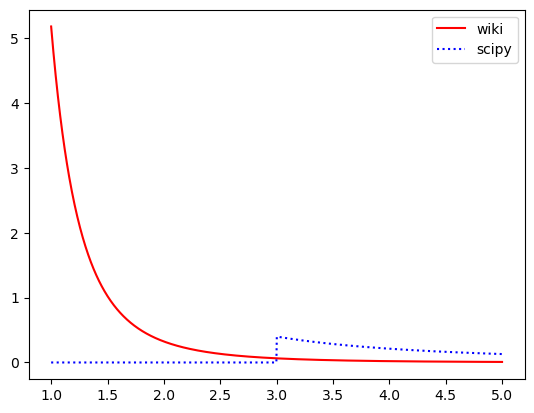

In [25]:
#NB: course teminology vs wiki terminology:  (k,beta) --> (x_m, alpha)
#: wiki vs scipy termonology:  (x_m, alpha) --> (b, scale)

beta=3 #(wiki: alpha,  scipy: sclae)
k=1.2 #(wiki: x_m,   scipy: b)

#Plot distributions to check whether interpretation is correct
xgrid = np.linspace(1,5,1000)
pareto_scipy_vals = sp.stats.pareto.pdf(x=xgrid, b=k, scale=beta)
def pareto_wiki(x, x_m, alpha):
    return alpha*x_m**alpha / (x**(alpha+1))

pareto_wiki_vals = pareto_wiki(xgrid, x_m=k, alpha=beta)
plt.plot(xgrid, pareto_wiki_vals, 'r', label="wiki")
plt.plot(xgrid, pareto_scipy_vals, ':b', label="scipy")
plt.legend()

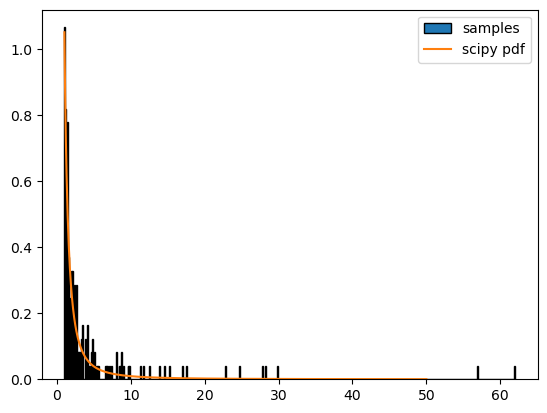

In [82]:
#  Generate Patero sample
np.random.seed(42)

beta_pareto=1 #(wiki: alpha,  scipy: sclae)
k_pareto=1.05 #(wiki: x_m,   scipy: b)

x_samples = sp.stats.pareto.rvs(b=k_pareto, scale=beta_pareto, size=n_pareto)

#Checking by plotting
xgrid = np.linspace(1,50,1000)
pareto_scipy_vals = sp.stats.pareto.pdf(x=xgrid, b=k_pareto, scale=beta_pareto)

plt.hist(x_samples, bins=500, edgecolor='black', density=True, label='samples')
plt.plot(xgrid, pareto_scipy_vals, label="scipy pdf")
plt.legend()
#plt.xlim(-0.1,50)
plt.show()

In [83]:
k = 100
n_pareto = 200

np.random.seed(42)
#Sample mean and median
mean_samp = np.mean(a=x_samples)
median_samp = np.median(a=x_samples)

#List for Bootstrap replicates (here: sample mean and median)
mean_BSreps = []
median_BSreps = []
for _ in range(k):
    #Draw from sample dist
    x_BS = np.random.choice(a=x_samples, size=n_pareto)
    mean_BSrep = np.mean(x_BS)
    median_BSrep = np.median(x_BS)

    #Append replicates
    mean_BSreps.append(mean_BSrep)
    median_BSreps.append(median_BSrep)

#Convert to np arrays
mean_BSreps = np.array(mean_BSreps)
median_BSreps = np.array(median_BSreps)

#Check dimensions
print("dimension")
print(np.shape(mean_BSreps))
print(np.shape(median_BSreps))

#Estimating Var(mean) and Var(median) as the sample variance of the BS replicates
var_mean = np.var(a=mean_BSreps, ddof=1)
var_median = np.var(a=median_BSreps, ddof=1)

print(f"results (for k={k}):")
print(f"mean_samp: {mean_samp:3f}")
print(f"median_samp: {median_samp:3f}")
print(f"var(mean): {var_mean:3f}")
print(f"var(median): {var_median:3f}")

dimension
(100,)
(100,)
results (for k=100):
mean_samp: 4.225955
median_samp: 1.914961
var(mean): 0.311343
var(median): 0.025838
